## 3D Channel flow with JAX

HydroGym contains a 3D channel flow written in differentiable language JAX. The channel flow is of size [$2 \pi, \pi, 2$], where $z$ is the wall-normal direction. The channel flow is run at $Re_{\tau}$ = 180, and is pre-configured to be controlled with 24 wall-normal jets evenly spaced throughout the wall. The observation value consists of evenly spaced x-velocity values sampled from $y^+ \approx 9$. 

### Initialize and test gymnax environment 

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

#####################################################
# Import channel flow and environment configuration #
#####################################################
from hydrogym.jax.envs.channel import *

env_config = {}
env = ChannelFlowSpectralEnv(env_config)
params = env.default_params

#####################################################
#   Reset environment to initial conditions         #
# provided in the HuggingFace initial fields folder #
#####################################################
key = jax.random.PRNGKey(0)
obs, state = env.reset_env(key, params)
print("Initial state shape U:", state.U.shape)
print("Initial state shape V:", state.U.shape)
print("Initial state shape W:", state.U.shape)
print("Initial mean observation value: ", jnp.mean(obs))

ERROR:2026-03-30 08:04:39,160:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/firedrake/firedrake/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/firedrake/firedrake/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/firedrake/firedrake/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


Initial state shape U: (72, 72, 72)
Initial state shape V: (72, 72, 72)
Initial state shape W: (72, 72, 72)
Initial mean observation value:  3.3731854661332368


### Test one environment step (params.nsteps internal RK steps) without control 

In [3]:
action = jnp.zeros((params.action_dim,))

obs, state, reward, done, info = env.step_env(key, state, action, params)

print("Mean observation value: ", jnp.mean(obs))
print("Reward:", reward)

Mean observation value:  3.3810941472675573
Reward: -0.3378005217734956


### Visualize U without control

After running the environment step, the state class contains (U,V,W) fields which can be accessed and visualized:

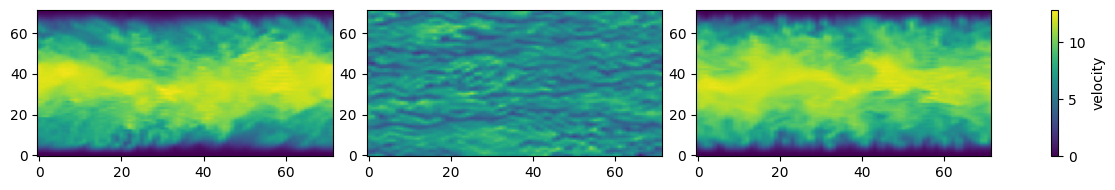

In [20]:
U = state.U
y_idx = 36
z_idx = 8
x_idx = 36
U_slice_xz = U[:, y_idx, :]
U_slice_xy = U[:, :, z_idx]
U_slice_yz = U[x_idx, :, :]

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
slices = [U_slice_xz, U_slice_xy, U_slice_yz]

vmin = min(s.min() for s in slices)
vmax = max(s.max() for s in slices)

for (
    ax,
    slice_,
) in zip(axes, slices):
    im = ax.imshow(
        slice_.T,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )
fig.subplots_adjust(right=0.9)

plt.tight_layout(rect=[0, 0, 1.25, 1])
fig.colorbar(im, ax=axes, label="velocity")
plt.show()

In [10]:
# Testing full suction jets #
key = jax.random.PRNGKey(0)
obs, state = env.reset_env(key, params)

# action = jax.random.normal(key, (params.action_dim,))
action = 0.01 * jnp.ones((params.action_dim,))
num_steps = 6

for i in range(num_steps):
    obs, state, reward, done, info = env.step_env(key, state, action, params)
    print("Mean observation value after environment step: ", jnp.mean(obs))
    print("Reward:", reward)

Mean observation value after environment step:  3.3811771453005943
Reward: -0.3379856556277938
Mean observation value after environment step:  3.374816954342459
Reward: -0.3296336066794982
Mean observation value after environment step:  3.3952557633014124
Reward: -0.32246759246707535
Mean observation value after environment step:  3.4049538883848918
Reward: -0.317317974468479
Mean observation value after environment step:  3.369506324681792
Reward: -0.31543620069660644
Mean observation value after environment step:  3.3887298110075403
Reward: -0.31826735862330213


### Visualize U after a few environment steps with control

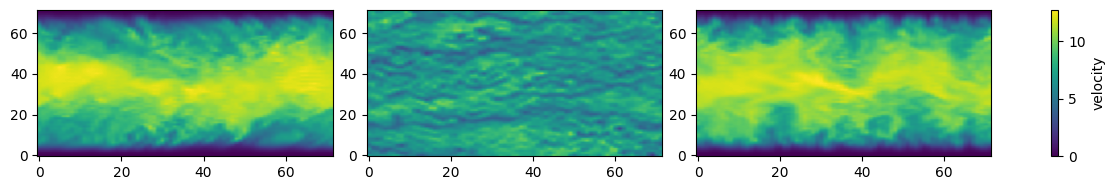

In [12]:
U = state.U
y_idx = 36
z_idx = 9
x_idx = 36
U_slice_xz = U[:, y_idx, :]
U_slice_xy = U[:, :, z_idx]
U_slice_yz = U[x_idx, :, :]

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
slices = [U_slice_xz, U_slice_xy, U_slice_yz]

vmin = min(s.min() for s in slices)
vmax = max(s.max() for s in slices)

for (
    ax,
    slice_,
) in zip(axes, slices):
    im = ax.imshow(
        slice_.T,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )
fig.subplots_adjust(right=0.9)

plt.tight_layout(rect=[0, 0, 1.25, 1])
fig.colorbar(im, ax=axes, label="velocity")
plt.show()